# A Transformer for English → Vietnamese translation — EVBCorpus

**Task:** machine translation. Given an English sentence, produce the Vietnamese one.

**Dataset:** [EVBCorpus / EVBNews](https://github.com/qhungngo/EVBCorpus) — 1,000 parallel news
documents, **45,308 sentence pairs**, aligned at sentence level *and* hand-aligned at word level.
From Ngo & Winiwarter, *Building an English-Vietnamese Bilingual Corpus for Machine Translation*
(IALP 2012).

**Architecture:** the encoder–decoder Transformer of
[Attention Is All You Need](https://arxiv.org/abs/1706.03762), following the structure of the
[TensorFlow transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer). Unlike
the previous project, the attention layers are `keras.layers.MultiHeadAttention` rather than
written by hand — that project was about the mechanism, this one is about the whole architecture
and the translation quality it produces.

**What the hand-aligned words buy us.** Cross-attention is supposed to learn alignment. This
corpus ships alignments a person wrote down, so the claim can be *checked* rather than admired:
section 9 measures how often the model's cross-attention points at the word a human said it
should.

### To run on Kaggle

1. **Settings → Accelerator → GPU T4 ×2.** Both are used this time; section 7 measures what the
   second one is actually worth.
2. **Settings → Internet → On.** The corpus is downloaded from GitHub.
3. Run all. About 30 minutes at the defaults.

**Scale:** the whole corpus is used — it is small. The knobs that cost time are `EPOCHS` and the
`RUN_*` flags in the config cell.

## 1. Attention, self-attention, masked attention

Everything in a Transformer is the same operation with different things plugged into it. A query
asks, keys advertise, values are what gets returned:

$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

`softmax(QKᵀ/√d_k)` is a table of weights — for each query, how much each key matches — and
multiplying by `V` returns the weighted average of the values. `√d_k` is there because dot
products of `d_k`-dimensional vectors grow with `d_k`, and large scores push the softmax into its
flat tails where gradients vanish.

**Multi-head** means doing this `h` times in parallel on `d_model/h`-dimensional slices and
concatenating. One attention distribution has to make one choice; eight heads can attend to the
subject, the verb and the punctuation at once.

The three uses below differ *only* in where Q, K, V come from and what gets masked:

| | Q from | K, V from | Masked | What it does |
|---|---|---|---|---|
| **Encoder self-attention** | source | source | padding only | every source word gathers context from the whole source, **both directions** |
| **Decoder masked self-attention** | target so far | target so far | padding **+ causal** | every target word sees only what has already been produced |
| **Cross-attention** | target | **source** (encoder output) | source padding | where translation actually happens — the alignment |

**Self-attention** is just the case where Q, K and V are the same sequence: the sentence looking at
itself. In the encoder that is what turns "bank" into either a river bank or a financial one,
because both readings' evidence sits in the same sentence.

**Masked (causal) attention** exists because of how training works. The whole target sentence is
fed to the decoder at once — teacher forcing — so without a mask, predicting the word at position
`t` could simply read position `t`. The model would reach near-zero loss and produce nothing at
inference, where those future positions do not exist. The mask is an upper-triangular
`-inf` added to the scores before the softmax, which makes each position's weights over the future
exactly zero.

Concretely, for a 4-token target the score matrix is masked like this before the softmax:

```
          t1    t2    t3    t4        <- keys (what can be looked at)
   t1  [  .   -inf  -inf  -inf ]
   t2  [  .     .   -inf  -inf ]
   t3  [  .     .     .   -inf ]
   t4  [  .     .     .     .  ]
   ^ queries (the position being predicted)
```

Note what is *not* masked: the encoder's matrix is full. The source sentence is entirely known
before translation starts, so hiding part of it from itself would only throw information away.
That asymmetry is the whole subject of the next section.

## 2. Why encoder–decoder, and not decoder-only

A decoder-only model can translate: put the source and the target in one sequence and predict
forward. Modern general-purpose LLMs are decoder-only and translate well. But for a *dedicated*
translation model at this scale, encoder–decoder is the better shape, for reasons that are
structural rather than a matter of taste:

**1. The source is fully known, so nothing should hide it from itself.** In an encoder, source
token *i* attends to every other source token, left and right. In a decoder-only model the whole
sequence is causal, so source token *i* cannot see source token *i+1* — the source representation
is built with one hand tied. For a language pair that reorders heavily this matters: Vietnamese
puts modifiers after nouns where English puts them before, so the English "angry youth" has to be
read whole before it can become "thanh niên phẫn nộ".

**2. Reading and writing are separated.** Encoder weights specialise in understanding the source,
decoder weights in producing fluent target text. A decoder-only model does both jobs with the same
parameters.

**3. The arithmetic is smaller.** Attention costs the square of the sequence length. A decoder-only
model over the concatenation pays `(S+T)² = S² + 2ST + T²`. Encoder–decoder pays `S²` in the
encoder, `T²` in the decoder and `S·T` in cross-attention — `S² + T² + ST`. It saves a whole `ST`
term, and the encoder half has no sequential dependency, so it parallelises cleanly.

**4. The source is encoded once.** Cross-attention keys and values are computed one time and
reused at every decoding step.

**Where decoder-only wins, and why it took over anyway:** one stack that handles every task, a
single pre-training objective, and simpler scaling. That is an argument about general-purpose
models, not about translation. The dedicated translation systems in use today — NLLB, MADLAD-400,
mBART — are still encoder–decoder, which is the honest form of this claim: decoder-only is not
worse at translating, it is a worse *fit* for a model whose only job is to translate.

In [20]:
import os, re, json, time, math, glob, random, subprocess, warnings, collections
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

IN_KAGGLE = os.path.isdir("/kaggle/input")
IN_COLAB = "google.colab" in str(globals().get("get_ipython", lambda: "")())

DATA = Path(os.environ.get("DATA_DIR") or ("/kaggle/working/data" if IN_KAGGLE else "./data"))
OUT = Path(os.environ.get("OUT_DIR") or ("/kaggle/working" if IN_KAGGLE else "./outputs"))
DATA.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
where = "kaggle" if IN_KAGGLE else "colab" if IN_COLAB else "local"
print(f"tensorflow {tf.__version__} | keras {tf.keras.__version__} | {where}")
print(f"GPU: {[g.name for g in gpus] or 'none — CPU only'}")

tensorflow 2.20.0 | keras 3.13.2 | kaggle
GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 3. Configuration

Every number in one cell. The `RUN_*` flags are the ones that cost time — each is a section that
can be skipped without breaking the rest.

In [21]:
SEED = 42

# -- data ---------------------------------------------------------------------------------
ARCHIVE_URL = "https://github.com/qhungngo/EVBCorpus/raw/master/EVBCorpus_EVBNews_v2.0.rar"
MAX_LEN = 64             # tokens per side; keeps 97.8% of the 45,308 pairs
VAL_DOCS, TEST_DOCS = 50, 50   # of 1,000 -- split by DOCUMENT, see section 4
EN_VOCAB, VI_VOCAB = 16_000, 8_000

# -- model (the tutorial's small configuration) -------------------------------------------
NUM_LAYERS = 4
D_MODEL = 128
NUM_HEADS = 8
DFF = 512
DROPOUT = 0.1

# -- training -----------------------------------------------------------------------------
PER_REPLICA_BATCH = 64   # global batch = this x number of GPUs
EPOCHS = 30
# The paper's 4000 assumes a much longer run than this one: at ~310 steps/epoch, 4000 steps is
# 13 epochs of warmup out of 30. Scaled to roughly 10% of training instead.
WARMUP_STEPS = 1000
LABEL_SMOOTHING = 0.1
PATIENCE = 5
MIXED_PRECISION = False

# -- decoding -----------------------------------------------------------------------------
BEAM_WIDTH = 4
BEAM_SENTENCES = 300     # beam search runs one sentence at a time; this caps how many
N_EXAMPLES = 6

# -- what to run (each is skippable) ------------------------------------------------------
USE_MULTI_GPU = True             # MirroredStrategy across every GPU present
RUN_GPU_BENCHMARK = True         # measure 1 GPU vs 2, instead of quoting a number (~1 min)
RUN_BEAM = True                  # beam search against greedy (~3 min)
RUN_DICTIONARY_BASELINE = True   # word-for-word translation from the corpus's gold alignments
RUN_ALIGNMENT_CHECK = True       # does cross-attention agree with the human word alignment?
RUN_REVERSE = False              # also train Vietnamese -> English (doubles training time)

# A tiny profile that also exercises the multi-replica path on a CPU, by splitting one CPU into
# two logical devices. Normal runs never set this.
if os.environ.get("SMOKE_TEST"):
    MAX_LEN, VAL_DOCS, TEST_DOCS = 24, 10, 10
    EN_VOCAB, VI_VOCAB = 2_000, 2_000
    NUM_LAYERS, D_MODEL, NUM_HEADS, DFF = 2, 32, 2, 64
    PER_REPLICA_BATCH, EPOCHS, WARMUP_STEPS, PATIENCE = 8, 1, 20, 1
    BEAM_SENTENCES, N_EXAMPLES = 5, 2
    SMOKE_DOCS = 60
    if not gpus:
        cpu = tf.config.list_physical_devices("CPU")[0]
        try:
            tf.config.set_logical_device_configuration(
                cpu, [tf.config.LogicalDeviceConfiguration()] * 2)
        except RuntimeError:
            pass    # already configured, e.g. the cell was re-run
    print("SMOKE TEST — tiny everything, the numbers below mean nothing")
else:
    SMOKE_DOCS = None

tf.keras.utils.set_random_seed(SEED)
if MIXED_PRECISION and gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

### The two GPUs

Kaggle offers **T4 ×2**, and this is the project where using both is worth it. `MirroredStrategy`
keeps a copy of the weights on each device, splits every global batch between them, and
all-reduces the gradients before the update. That sync is the overhead, so the gain is never a
clean 2× — the previous project in this repo measured **1.6–1.9×** for an LSTM.

A Transformer is a better fit than an LSTM for this: the encoder has no sequential dependency, so
there is more work per step to hide the sync behind. Section 7 measures it here rather than
assuming the old number carries over.

Two rules that are not optional:

- **Build and compile the model inside `strategy.scope()`.** Variables created outside it are not
  mirrored, and the replicas silently train separate copies.
- **Batch the dataset with the *global* batch size.** Each replica then sees `PER_REPLICA_BATCH`.

In [22]:
if USE_MULTI_GPU and len(gpus) > 1:
    strategy = tf.distribute.MirroredStrategy()
elif os.environ.get("SMOKE_TEST") and not gpus:
    logical = tf.config.list_logical_devices("CPU")
    strategy = (tf.distribute.MirroredStrategy([d.name for d in logical])
                if len(logical) > 1 else tf.distribute.get_strategy())
else:
    strategy = tf.distribute.get_strategy()

N_REPLICAS = strategy.num_replicas_in_sync
GLOBAL_BATCH = PER_REPLICA_BATCH * N_REPLICAS
print(f"{type(strategy).__name__} over {N_REPLICAS} replica(s)")
print(f"batch: {PER_REPLICA_BATCH} per replica x {N_REPLICAS} = {GLOBAL_BATCH} global")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
MirroredStrategy over 2 replica(s)
batch: 64 per replica x 2 = 128 global


## 4. The corpus

EVBNews ships as a `.rar` archive of 1,000 SGML files. Each file holds sentence pairs and, for
almost all of them, a hand-written word alignment:

```xml
<spair id='2'>
<s id='en2'>Fenqing is a Chinese word which literally means " angry youth " .</s>
<s id='vn2'>Fenqing là một từ tiếng Hoa mà nghĩa đen là " thanh niên phẫn nộ " .</s>
<a id='ev2'>1-1;2-2;3-3;4-5,6;5-4;6-7;7-8,9;8-10;10-14,15;11-12,13;</a>
</spair>
```

The alignment reads `english_index-vietnamese_index[,index...]`, 1-based: English word 4
(*Chinese*) covers Vietnamese words 5 and 6 (*tiếng Hoa*), and English 10–11 (*angry youth*)
maps to Vietnamese 14,15 and 12,13 — reversed, because Vietnamese puts the modifier after the noun.

**`.rar` needs an external tool**, and which one exists depends on the machine: macOS `tar` is
bsdtar and reads RAR directly, GNU `tar` on Linux does not. The cell below tries the tools in
order and installs one if none is present.

In [23]:
def download(url, destination):
    import requests
    if destination.exists():
        return destination
    print(f"downloading {destination.name} ...", end=" ", flush=True)
    try:
        with requests.get(url, stream=True, timeout=180) as r:
            r.raise_for_status()
            with open(destination, "wb") as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
    except Exception as e:
        destination.unlink(missing_ok=True)
        raise RuntimeError(f"could not download {url} ({e}).\n"
                           "On Kaggle: Settings -> Internet -> On.") from e
    print(f"{destination.stat().st_size / 1e6:.1f} MB")
    return destination


def extract_rar(archive, into):
    """Unpack a .rar with whatever tool this machine happens to have.

    No pure-Python option exists: `rarfile` is a wrapper and still needs a backend. bsdtar
    (= macOS `tar`) reads RAR through libarchive; `unar` is the one that is packaged everywhere.
    """
    into.mkdir(parents=True, exist_ok=True)
    if list(into.glob("*.sgml")):
        return "already extracted"

    candidates = [["tar", "-xf", str(archive), "-C", str(into)],
                  ["bsdtar", "-xf", str(archive), "-C", str(into)],
                  ["unar", "-q", "-f", "-o", str(into), str(archive)],
                  ["7z", "x", f"-o{into}", "-y", str(archive)],
                  ["unrar", "x", "-y", str(archive), f"{into}/"]]
    for attempt in range(2):
        for command in candidates:
            try:
                subprocess.run(command, check=True, capture_output=True)
            except Exception:
                continue
            if list(into.glob("*.sgml")):
                return command[0]
        if attempt == 0:      # nothing worked -- try to install a backend, then go round again
            print("  no rar tool found, installing one ...")
            for install in (["apt-get", "-qq", "install", "-y", "unar"],
                            ["apt-get", "-qq", "install", "-y", "libarchive-tools"]):
                try:
                    subprocess.run(install, check=True, capture_output=True, timeout=300)
                except Exception:
                    continue
    raise RuntimeError(
        "could not unpack the .rar. Install one of unar / libarchive-tools / p7zip and re-run:\n"
        "    !apt-get install -y unar")


mounted = glob.glob("/kaggle/input/**/*.sgml", recursive=True) if IN_KAGGLE else []
if mounted:
    CORPUS = Path(mounted[0]).parent          # someone attached the extracted corpus as a dataset
    print(f"using the attached dataset at {CORPUS}")
else:
    CORPUS = DATA / "evbnews"
    tool = extract_rar(download(ARCHIVE_URL, DATA / "evbnews.rar"), CORPUS)
    print(f"extracted with {tool}")
print(f"{len(list(CORPUS.glob('*.sgml'))):,} documents")

extracted with already extracted
1,000 documents


### Splitting by document, not by sentence

Sentences from the same news article share names, dates and phrasing. Shuffling 45,308 sentences
and cutting off a validation slice puts sentences from the *same article* on both sides, and the
score that comes back is partly memorisation. The split below holds out whole documents.

In [24]:
SPAIR = re.compile(r"<spair id='\d+'>(.*?)</spair>", re.S)
EN_S = re.compile(r"<s id='en\d+'>(.*?)</s>", re.S)
VI_S = re.compile(r"<s id='vn\d+'>(.*?)</s>", re.S)
ALIGN = re.compile(r"<a id='ev\d+'>(.*?)</a>", re.S)


def parse_document(path):
    """Every (english, vietnamese, alignment) triple in one SGML file."""
    text = path.read_text(encoding="utf-8", errors="replace")
    rows = []
    for block in SPAIR.findall(text):
        en, vi, al = EN_S.search(block), VI_S.search(block), ALIGN.search(block)
        if en and vi:
            rows.append((en.group(1).strip(), vi.group(1).strip(),
                         al.group(1).strip() if al else ""))
    return rows


documents = sorted(CORPUS.glob("*.sgml"))
if SMOKE_DOCS:
    documents = documents[:SMOKE_DOCS]
random.Random(SEED).shuffle(documents)
splits = {"test": documents[:TEST_DOCS],
          "validation": documents[TEST_DOCS:TEST_DOCS + VAL_DOCS],
          "train": documents[TEST_DOCS + VAL_DOCS:]}

data = {}
for name, paths in splits.items():
    rows = [row for path in paths for row in parse_document(path)]
    kept = [(en, vi, al) for en, vi, al in rows
            if 1 <= len(en.split()) <= MAX_LEN - 2 and 1 <= len(vi.split()) <= MAX_LEN - 2]
    data[name] = kept
    print(f"{name:11} {len(paths):>4} docs  {len(rows):>6,} pairs  "
          f"-> {len(kept):>6,} within {MAX_LEN} tokens ({len(kept)/max(len(rows),1):.1%})")

print("\nexample pair:")
print("  EN:", data["train"][0][0])
print("  VI:", data["train"][0][1])
print("  al:", data["train"][0][2][:70], "...")

test          50 docs   2,862 pairs  ->  2,793 within 64 tokens (97.6%)
validation    50 docs   2,862 pairs  ->  2,791 within 64 tokens (97.5%)
train        900 docs  39,584 pairs  -> 38,523 within 64 tokens (97.3%)

example pair:
  EN: Camera megapixels : Why more is n't always better ( Part 1 )
  VI: Số megapixel Máy ảnh : Vì sao nhiều " chấm " hơn không phải lúc nào cũng tốt hơn ( Phần 1 )
  al: 1-3,4;2-1,2;4-6,7;5-12;8-15,16,17;9-18,19;11-21;12-22; ...


### What the two languages look like

The interesting number here is the vocabulary. English has more than twice as many distinct
word types as Vietnamese has distinct syllables, even though the Vietnamese side is 37% *longer*
in tokens. Vietnamese writes syllables separated by spaces and its syllable inventory is close to
a closed set, so a plain word-level vocabulary covers it almost completely — which is why this
project does not need subword tokenisation to avoid drowning in `<unk>`.

In [25]:
def tokens(sentence):
    """EVBNews is already tokenised -- punctuation is space-separated -- so this is the job."""
    return sentence.lower().split()


lengths = {"EN": np.array([len(tokens(en)) for en, _, _ in data["train"]]),
           "VI": np.array([len(tokens(vi)) for _, vi, _ in data["train"]])}
for name, L in lengths.items():
    print(f"{name}: mean {L.mean():5.1f}  median {np.median(L):4.0f}  "
          f"p95 {np.percentile(L, 95):4.0f}  max {L.max()}")

counts = {"EN": collections.Counter(w for en, _, _ in data["train"] for w in tokens(en)),
          "VI": collections.Counter(w for _, vi, _ in data["train"] for w in tokens(vi))}
print()
for name, counter in counts.items():
    total, ranked = sum(counter.values()), counter.most_common()
    chosen = EN_VOCAB if name == "EN" else VI_VOCAB
    print(f"{name}: {len(counter):,} distinct over {total:,} tokens")
    for size in (4_000, 8_000, 16_000, 24_000):
        if size <= len(ranked):
            covered = sum(n for _, n in ranked[:size]) / total
            print(f"    vocab {size:>6,} covers {covered:6.2%}"
                  f"{'   <-' if size == chosen else ''}")

EN: mean  18.6  median   18  p95   37  max 60
VI: mean  25.2  median   24  p95   50  max 62

EN: 31,364 distinct over 715,844 tokens
    vocab  4,000 covers 88.41%
    vocab  8,000 covers 93.80%
    vocab 16,000 covers 97.50%   <-
    vocab 24,000 covers 98.97%
VI: 14,071 distinct over 972,099 tokens
    vocab  4,000 covers 98.09%
    vocab  8,000 covers 99.35%   <-


In [26]:
PAD, UNK, BOS, EOS = 0, 1, 2, 3
SPECIALS = ["<pad>", "<unk>", "<bos>", "<eos>"]


class Vocab:
    """Word <-> id for one language."""

    def __init__(self, counter, size):
        self.itos = SPECIALS + [w for w, _ in counter.most_common(size - len(SPECIALS))]
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, sentence, length, with_markers):
        ids = [self.stoi.get(w, UNK) for w in tokens(sentence)]
        if with_markers:
            ids = [BOS] + ids[: length - 2] + [EOS]
        else:
            ids = ids[:length]
        return ids + [PAD] * (length - len(ids))

    def decode(self, ids):
        out = []
        for i in ids:
            if i in (EOS, PAD):
                break
            if i != BOS:
                out.append(self.itos[i])
        return out


en_vocab = Vocab(counts["EN"], EN_VOCAB)
vi_vocab = Vocab(counts["VI"], VI_VOCAB)
print(f"EN vocabulary {len(en_vocab):,} | VI vocabulary {len(vi_vocab):,}")


def encode_split(rows):
    source = np.array([en_vocab.encode(en, MAX_LEN, False) for en, _, _ in rows], np.int32)
    target = np.array([vi_vocab.encode(vi, MAX_LEN, True) for _, vi, _ in rows], np.int32)
    return source, target


encoded = {name: encode_split(rows) for name, rows in data.items()}


def make_dataset(split, shuffle):
    """((source, target_in), target_out) -- target_out is target_in shifted one left."""
    source, target = encoded[split]
    ds = tf.data.Dataset.from_tensor_slices(((source, target[:, :-1]), target[:, 1:]))
    if shuffle:
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(GLOBAL_BATCH, drop_remainder=True).prefetch(tf.data.AUTOTUNE)


train_ds, val_ds = make_dataset("train", True), make_dataset("validation", False)
(src_b, tgt_in_b), tgt_out_b = next(iter(train_ds))
print(f"batch: source {src_b.shape}  target in {tgt_in_b.shape}  target out {tgt_out_b.shape}")
print("in :", " ".join(vi_vocab.itos[i] for i in tgt_in_b[0, :8].numpy()))
print("out:", " ".join(vi_vocab.itos[i] for i in tgt_out_b[0, :8].numpy()))

EN vocabulary 16,000 | VI vocabulary 8,000
batch: source (128, 64)  target in (128, 63)  target out (128, 63)
in : <bos> phelan thừa nhận mu là đội bóng
out: phelan thừa nhận mu là đội bóng đang


## 5. The Transformer

Built bottom-up, each piece a small layer.

**Padding masks are explicit arguments here**, not Keras's automatic `mask_zero` propagation.
That propagation stops at the first layer that does not declare `supports_masking`, and every
custom layer below is one — so the mask would be silently dropped before it reached any attention
layer, and the model would attend over padding while everything still ran. The check at the end of
this section is there because that failure is invisible otherwise.

**Positional encoding.** Attention is a weighted sum, and a sum does not care about order — with
no positional signal, "dog bites man" and "man bites dog" are the same input. Fixed sine and
cosine waves of different frequencies are added to the embeddings, giving every position a unique
pattern that the model can use to work out relative distance. The embedding is scaled by
`√d_model` first so the token signal is not drowned out by the positional one.

**Each encoder layer** is self-attention then a feed-forward network, each wrapped in a residual
connection and a layer norm. The residual is what lets the stack be deep: the gradient has an
unobstructed path from the loss to every layer.

**Each decoder layer** adds a middle step — causal self-attention, then *cross*-attention into the
encoder output, then the feed-forward. That middle step is the translation.

In [27]:
def positional_encoding(length, depth):
    """Sine and cosine waves of geometrically spaced frequencies, one column pair each."""
    half = depth // 2
    positions = np.arange(length)[:, None]                      # (L, 1)
    depths = np.arange(half)[None, :] / half                    # (1, D/2)
    angles = positions / (10_000 ** depths)                     # (L, D/2)
    return tf.cast(np.concatenate([np.sin(angles), np.cos(angles)], axis=-1), tf.float32)


class PositionalEmbedding(tf.keras.layers.Layer):
    """Token embedding, scaled, plus the positional signal."""

    def __init__(self, vocab_size, d_model, max_len=2048, **kw):
        super().__init__(**kw)
        self.d_model = d_model
        # mask_zero=False on purpose. Keras propagates an embedding mask only through layers that
        # declare they support masking, and silently DROPS it at the first one that does not --
        # which is every custom layer below. Masks here are passed as explicit arguments instead,
        # so there is nothing to lose track of. The check at the end of section 5 verifies it.
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = positional_encoding(max_len, d_model)

    def call(self, x):
        length = tf.shape(x)[1]
        x = self.embedding(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        return x + self.pos_encoding[tf.newaxis, :length, :]

In [28]:
class BaseAttention(tf.keras.layers.Layer):
    """Multi-head attention + residual + layer norm, the shape all three uses share."""

    def __init__(self, **kw):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kw)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add = tf.keras.layers.Add()


class GlobalSelfAttention(BaseAttention):
    """Encoder: the source looking at itself, in both directions.

    `mask` is (batch, source_len), True at real tokens. MultiHeadAttention wants
    (batch, query_len, key_len), and (batch, 1, key_len) broadcasts over the query axis: every
    query is forbidden from attending to the same padded keys.
    """

    def call(self, x, mask):
        attended = self.mha(query=x, key=x, value=x, attention_mask=mask[:, None, :])
        return self.layernorm(self.add([x, attended]))


class CausalSelfAttention(BaseAttention):
    """Decoder: the target looking at itself, but only backwards.

    Two masks at once. `use_causal_mask=True` is the upper-triangular -inf -- without it the model
    reads the answer off position t during teacher forcing and produces nothing at inference.
    The padding mask is separate, and Keras ANDs the two together.
    """

    def call(self, x, mask):
        attended = self.mha(query=x, key=x, value=x, attention_mask=mask[:, None, :],
                            use_causal_mask=True)
        return self.layernorm(self.add([x, attended]))


class CrossAttention(BaseAttention):
    """Decoder: the target looking at the source. This is where translation happens.

    The mask is the *source* mask -- the target is asking, so what has to be hidden is padding on
    the side being read.
    """

    def call(self, x, context, source_mask):
        attended, scores = self.mha(query=x, key=context, value=context,
                                    attention_mask=source_mask[:, None, :],
                                    return_attention_scores=True)
        self.last_attention_scores = scores      # (batch, heads, target_len, source_len)
        return self.layernorm(self.add([x, attended]))


class FeedForward(tf.keras.layers.Layer):
    """Two dense layers per position, widening to dff and back."""

    def __init__(self, d_model, dff, dropout, **kw):
        super().__init__(**kw)
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation="relu"),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout),
        ])
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add = tf.keras.layers.Add()

    def call(self, x):
        return self.layernorm(self.add([x, self.seq(x)]))

In [29]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.self_attention = GlobalSelfAttention(num_heads=num_heads, key_dim=d_model // num_heads,
                                                  dropout=dropout)
        self.ffn = FeedForward(d_model, dff, dropout)

    def call(self, x, mask):
        return self.ffn(self.self_attention(x, mask))


class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, **kw):
        super().__init__(**kw)
        self.causal_self_attention = CausalSelfAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)
        self.cross_attention = CrossAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)
        self.ffn = FeedForward(d_model, dff, dropout)

    def call(self, x, context, target_mask, source_mask):
        x = self.causal_self_attention(x, target_mask)
        x = self.cross_attention(x, context, source_mask)
        self.last_attention_scores = self.cross_attention.last_attention_scores
        return self.ffn(x)


class Transformer(tf.keras.Model):
    """Encoder-decoder Transformer: source ids + target-so-far ids -> logits over the target vocabulary."""

    def __init__(self, num_layers, d_model, num_heads, dff, source_vocab, target_vocab, dropout):
        super().__init__()
        self.source_embedding = PositionalEmbedding(source_vocab, d_model)
        self.target_embedding = PositionalEmbedding(target_vocab, d_model)
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.encoder_layers = [EncoderLayer(d_model, num_heads, dff, dropout)
                               for _ in range(num_layers)]
        self.decoder_layers = [DecoderLayer(d_model, num_heads, dff, dropout)
                               for _ in range(num_layers)]
        self.final = tf.keras.layers.Dense(target_vocab, dtype="float32")

    def encode(self, source):
        """Returns (encoder output, source padding mask) -- the mask travels with the context."""
        mask = source != PAD
        x = self.dropout(self.source_embedding(source))
        for layer in self.encoder_layers:
            x = layer(x, mask)
        return x, mask

    def decode(self, target_in, context, source_mask):
        target_mask = target_in != PAD
        x = self.dropout(self.target_embedding(target_in))
        for layer in self.decoder_layers:
            x = layer(x, context, target_mask, source_mask)
        return self.final(x)

    def call(self, inputs):
        source, target_in = inputs
        context, source_mask = self.encode(source)
        return self.decode(target_in, context, source_mask)

    def attention_scores(self):
        """Cross-attention of every decoder layer from the last call. (layers, B, heads, T, S)."""
        return [layer.last_attention_scores for layer in self.decoder_layers]

### The learning-rate schedule, the loss, and one check

**Warmup.** The paper's schedule ramps the learning rate up linearly for `warmup_steps` and then
decays it as `1/√step`. Adam's second-moment estimate is unreliable in the first few hundred
steps, and a Transformer diverges readily if it is given a full learning rate then.

**Label smoothing (0.1)** stops the model from driving the correct logit to infinity, which is
what overconfidence looks like on a 40k-pair corpus. It also makes the loss value hard to read,
and that has a consequence worth stating before the numbers arrive.

Smoothing the target to `(1-eps)*onehot + eps/V` makes the loss

```
    (1 - eps) * (-log p_true)   +   eps * mean_over_vocab(-log p_v)
     the usual cross-entropy         a penalty on being confident
```

The second term **grows as the model sharpens** — a confident model pushes most of the vocabulary
towards probability zero, and `-log 0` is large. So validation loss can rise while the model is
still getting better, and it is measuring confidence as much as quality. Two consequences:

- The loss does not approach zero. A run ending near 5 with 70% token accuracy is normal here, not
  a model that failed to converge.
- **Early stopping monitors `val_masked_accuracy`, not `val_loss`.** On the first run of this
  notebook they disagreed by three epochs — validation loss bottomed at epoch 6 while accuracy
  kept improving to epoch 9 — and monitoring the loss restored the worse of the two checkpoints.

**The masked-metric trap from the previous project applies here too.** `mask_zero=True` makes
Keras hand the propagated mask to a function metric as `sample_weight`, which it cannot apply to
the scalar the function returned. Accuracy is a `Metric` subclass for that reason.

The cell after that is a **test that the padding mask actually works**: change nothing but the
padding of a batch and confirm the logits at the real positions do not move. Attention masking is
the kind of thing that is easy to believe and hard to see, and if it were broken, everything below
would still run and quietly be wrong.

In [30]:
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear ramp for warmup_steps, then 1/sqrt(step) decay -- the schedule from the paper."""

    def __init__(self, d_model, warmup_steps):
        super().__init__()
        self.d_model = float(d_model)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(tf.maximum(step, 1.0)), step * self.warmup_steps ** -1.5)

    def get_config(self):
        return {"d_model": self.d_model, "warmup_steps": self.warmup_steps}


def masked_loss(y_true, y_pred):
    """Cross-entropy over real tokens only, with label smoothing.

    Written out rather than via `categorical_crossentropy(label_smoothing=...)`, which needs a
    one-hot target: at batch 128 x 63 positions x 8000 words that is 258 MB for a tensor whose
    every row is a single 1. Smoothing the target to `(1-eps)*onehot + eps/V` gives

        loss = (1-eps) * (-log p_true)  +  eps * mean_v(-log p_v)

    which needs only the log-softmax that is being computed anyway.
    """
    y_true = tf.cast(y_true, tf.int32)     # Keras hands targets over as float32
    log_probs = tf.nn.log_softmax(y_pred, axis=-1)
    nll = -tf.gather(log_probs, y_true, batch_dims=2)          # (B, T)
    uniform = -tf.reduce_mean(log_probs, axis=-1)              # (B, T)
    per_token = (1 - LABEL_SMOOTHING) * nll + LABEL_SMOOTHING * uniform

    mask = tf.cast(y_true != PAD, per_token.dtype)
    return tf.reduce_sum(per_token * mask) / tf.reduce_sum(mask)


class MaskedAccuracy(tf.keras.metrics.Metric):
    """Token accuracy over the positions that are not padding."""

    def __init__(self, name="masked_accuracy", **kw):
        super().__init__(name=name, **kw)
        self.correct = self.add_weight(name="correct", initializer="zeros")
        self.total = self.add_weight(name="total", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        mask = tf.cast(y_true != PAD, tf.float32)
        hit = tf.cast(tf.argmax(y_pred, -1, output_type=tf.int32) == y_true, tf.float32)
        self.correct.assign_add(tf.reduce_sum(hit * mask))
        self.total.assign_add(tf.reduce_sum(mask))

    def result(self):
        return self.correct / (self.total + 1e-9)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)


def build_model(source_vocab, target_vocab, sample=None):
    """Build and compile. Call this INSIDE `strategy.scope()`.

    A subclassed model creates its variables on the first call, not in `__init__`. Calling it
    outside the scope creates unmirrored variables, and training then fails with
    `colocate_vars_with must only be passed a variable created in this Strategy.scope()` --
    which names the scope but not the line that left it. Hence `sample`: the first call happens
    here, wherever `build_model` itself was invoked.
    """
    model = Transformer(NUM_LAYERS, D_MODEL, NUM_HEADS, DFF, source_vocab, target_vocab, DROPOUT)
    if sample is not None:
        model(sample)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(WarmupSchedule(D_MODEL, WARMUP_STEPS),
                                           beta_1=0.9, beta_2=0.98, epsilon=1e-9),
        loss=masked_loss, metrics=[MaskedAccuracy()])
    return model

In [31]:
# Does the padding mask actually mask?
#
# The test has to be chosen carefully. Filling the padded slots with garbage does NOT test this:
# the mask is derived from the ids, so garbage in a padded slot simply becomes a real token and
# the output is *supposed* to change. What masking actually promises is that padding is inert --
# so add MORE of it. Sixteen extra pad columns give the encoder sixteen more positions to attend
# to; if they are properly masked out, every logit is bit-for-bit what it was.
probe = build_model(len(en_vocab), len(vi_vocab))   # outside the scope on purpose: never trained
source, target_in = src_b.numpy().copy(), tgt_in_b.numpy().copy()
padded = np.concatenate([source, np.zeros((source.shape[0], 16), np.int32)], axis=1)

drift = np.abs(probe((source, target_in)).numpy() - probe((padded, target_in)).numpy()).max()
print(f"largest logit change when 16 pad columns are appended to the source: {drift:.2e}")
print("padding mask works" if drift < 1e-4 else "PADDING IS LEAKING -- everything below is suspect")
del probe

largest logit change when 16 pad columns are appended to the source: 0.00e+00
padding mask works


## 6. What the second GPU is worth

Measured rather than assumed: the same model, the same number of steps, on one device and on all
of them.

In [32]:
def time_steps(scope_strategy, batch, steps=30):
    """Seconds per step for a fresh model under one distribution strategy."""
    with scope_strategy.scope():
        model = build_model(len(en_vocab), len(vi_vocab), sample=(src_b, tgt_in_b))
    source, target = encoded["train"]
    ds = (tf.data.Dataset.from_tensor_slices(((source, target[:, :-1]), target[:, 1:]))
          .batch(batch, drop_remainder=True).repeat().prefetch(tf.data.AUTOTUNE))
    model.fit(ds, steps_per_epoch=5, epochs=1, verbose=0, shuffle=False)   # warm up / trace
    started = time.time()
    model.fit(ds, steps_per_epoch=steps, epochs=1, verbose=0, shuffle=False)
    return (time.time() - started) / steps


if RUN_GPU_BENCHMARK and N_REPLICAS > 1:
    single = tf.distribute.OneDeviceStrategy("/gpu:0" if gpus else "/cpu:0")
    one = time_steps(single, PER_REPLICA_BATCH)
    many = time_steps(strategy, GLOBAL_BATCH)
    print(f"1 replica : {one * 1000:6.1f} ms/step at batch {PER_REPLICA_BATCH}")
    print(f"{N_REPLICAS} replicas: {many * 1000:6.1f} ms/step at batch {GLOBAL_BATCH}")
    print(f"speedup on samples/second: {(GLOBAL_BATCH / many) / (PER_REPLICA_BATCH / one):.2f}x"
          f"  (perfect scaling would be {N_REPLICAS}.00x)")
    GPU_SPEEDUP = (GLOBAL_BATCH / many) / (PER_REPLICA_BATCH / one)
else:
    GPU_SPEEDUP = None
    print("skipped (needs more than one replica, and RUN_GPU_BENCHMARK)")

INFO:tensorflow:Collective all_reduce tensors: 170 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce IndexedSlices: 2 all_reduces, num_devices =2, group_size = 2, implementation = CommunicationImplementation.NCCL
1 replica :   97.6 ms/step at batch 64
2 replicas:  125.5 ms/step at batch 128
speedup on samples/second: 1.56x  (perfect scaling would be 2.00x)


## 7. Training

In [33]:
with strategy.scope():
    model = build_model(len(en_vocab), len(vi_vocab), sample=(src_b, tgt_in_b))
model.summary()
print(f"\n{model.count_params():,} parameters")

Model: "transformer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positional_embedding_14         │ ?                      │     2,048,000 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_15         │ ?                      │     1,024,000 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_147 (Dropout)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_28 (EncoderLayer) │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_29 (EncoderLayer) │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_30 (EncoderLayer) │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer_31 (EncoderLayer) │ ?                      │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_28 (DecoderLayer) │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_29 (DecoderLayer) │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_30 (DecoderLayer) │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_layer_31 (DecoderLayer) │ ?                      │       264,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_135 (Dense)               │ (128, 63, 8000)        │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,955,392 (22.72 MB)

 Trainable params: 5,955,392 (22.72 MB)

 Non-trainable params: 0 (0.00 B)


5,955,392 parameters


In [34]:
started = time.time()
history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2, shuffle=False,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_masked_accuracy", mode="max",
                                                patience=PATIENCE, restore_best_weights=True)])
TRAIN_SECONDS = time.time() - started
EPOCHS_RUN = len(history.history["loss"])
best_by_accuracy = int(np.argmax(history.history["val_masked_accuracy"])) + 1
best_by_loss = int(np.argmin(history.history["val_loss"])) + 1
print(f"\n{TRAIN_SECONDS / 60:.1f} min over {EPOCHS_RUN} epochs "
      f"({TRAIN_SECONDS / EPOCHS_RUN:.0f} s/epoch)")
print(f"best val accuracy {max(history.history['val_masked_accuracy']):.4f} at epoch "
      f"{best_by_accuracy}  (val loss bottomed at epoch {best_by_loss})")

Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 170 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce IndexedSlices: 2 all_reduces, num_devices =2, group_size = 2, implementation = CommunicationImplementation.NCCL
300/300 - 64s - 213ms/step - loss: 14.2001 - masked_accuracy: 0.1098 - val_loss: 11.3710 - val_masked_accuracy: 0.2266
Epoch 2/30
300/300 - 36s - 121ms/step - loss: 10.1294 - masked_accuracy: 0.2953 - val_loss: 9.3896 - val_masked_accuracy: 0.3383
Epoch 3/30
300/300 - 36s - 121ms/step - loss: 8.5882 - masked_accuracy: 0.3948 - val_loss: 8.6703 - val_masked_accuracy: 0.3906
Epoch 4/30
300/300 - 36s - 121ms/step - loss: 7.7083 - masked_accuracy: 0.4597 - val_loss: 8.2231 - val_masked_accuracy: 0.4257
Epoch 5/30
300/300 - 36s - 120ms/step - loss: 6.9200 - masked_accuracy: 0.5220 - val_loss: 7.9707 - val_masked_accuracy: 0.4496
Epoch 6/30
300/300 - 37s - 122ms/step - loss:

## 8. Translating

**Greedy** takes the most likely token at every step. It is fast and batched, and it is what the
main numbers are computed on.

**Beam search** keeps the `BEAM_WIDTH` best partial translations instead of one, and scores them
by total log-probability divided by length — without the length division, beam search
systematically prefers short translations, because every extra word multiplies in another
probability below 1. It runs one source sentence at a time here, so it is capped at
`BEAM_SENTENCES`.

Both re-run the decoder over the whole prefix at each step rather than caching keys and values.
That is `O(T²)` work for `T ≤ 64`, and it keeps generation using exactly the same code path as
training.

**Decoding runs on one GPU, not two.** `MirroredStrategy` distributes *training* steps; a
hand-written generation loop is ordinary eager code and uses a single device. That is the right
trade here — the loop is sequential by nature, so there is nothing to split — but it means the
decode timings below should not be compared against the training throughput above.

In [35]:
# Two notes before the loops below.
#
# `@tf.function` is not decoration here, it is most of the speed. Decoding a test set is ~1,400
# calls and beam search ~19,000, and eager mode pays full Python dispatch on every one of them --
# which for a 6M-parameter model costs more than the arithmetic does. Traced, the same loop runs
# several times faster. `reduce_retracing=True` matters because the prefix grows by one token per
# step: without it TensorFlow would trace a new graph for every length.
#
# The warning this silences is real but harmless: at the first decoding step the target is one
# token long, so causal self-attention softmaxes over a single key and Keras points out that the
# result is always 1.0. It is -- the first token can only attend to itself.
warnings.filterwarnings("ignore", message=r".*softmax over axis.*")


@tf.function(reduce_retracing=True)
def decode_step(sequence, context, source_mask):
    return model.decode(sequence, context, source_mask)


def greedy_translate(sources, batch_size=128):
    """Batched greedy decoding. Returns lists of Vietnamese tokens."""
    outputs = []
    for start in range(0, len(sources), batch_size):
        source = tf.constant(sources[start:start + batch_size])
        context, source_mask = model.encode(source)
        if start == 0:
            # Inference runs on one device: MirroredStrategy is a training construct and does
            # nothing for a hand-written decode loop. This says which device that is.
            print(f"  decoding on {context.device}")
        n = int(source.shape[0])
        sequence = np.full((n, 1), BOS, np.int32)
        done = np.zeros(n, bool)
        for _ in range(MAX_LEN - 1):
            logits = decode_step(tf.constant(sequence), context, source_mask)[:, -1, :].numpy()
            logits[:, [PAD, BOS]] = -1e9
            nxt = logits.argmax(-1).astype(np.int32)
            nxt[done] = PAD
            done |= nxt == EOS
            sequence = np.concatenate([sequence, nxt[:, None]], axis=1)
            if done.all():
                break
        outputs.extend(vi_vocab.decode(row[1:]) for row in sequence)
    return outputs


def beam_translate(source_ids, beam=BEAM_WIDTH, alpha=1.0):
    """Beam search for one source sentence. `alpha` is the length normalisation exponent."""
    context, source_mask = model.encode(tf.constant(source_ids[None, :]))
    context = tf.repeat(context, beam, axis=0)
    source_mask = tf.repeat(source_mask, beam, axis=0)
    sequences = np.full((beam, 1), BOS, np.int32)
    scores = np.full(beam, -1e9, np.float32)
    scores[0] = 0.0                     # only one live beam at the start, or all beams tie
    finished = []

    for step in range(MAX_LEN - 1):
        logits = decode_step(tf.constant(sequences), context, source_mask)[:, -1, :].numpy()
        logits[:, [PAD, BOS]] = -1e9
        logprobs = logits - np.log(np.exp(logits - logits.max(-1, keepdims=True))
                                   .sum(-1, keepdims=True)) - logits.max(-1, keepdims=True)
        candidates = scores[:, None] + logprobs
        flat = candidates.ravel().argsort()[-beam:][::-1]
        beam_index, token = flat // logprobs.shape[1], flat % logprobs.shape[1]
        sequences = np.concatenate([sequences[beam_index], token[:, None].astype(np.int32)], 1)
        scores = candidates.ravel()[flat]

        for i, t in enumerate(token):
            if t == EOS:
                length = (sequences.shape[1] - 1) ** alpha
                finished.append((scores[i] / length, sequences[i].copy()))
                scores[i] = -1e9
        if len(finished) >= beam:
            break

    if not finished:
        finished = [(scores[0] / max(sequences.shape[1] - 1, 1) ** alpha, sequences[0])]
    return vi_vocab.decode(max(finished, key=lambda pair: pair[0])[1][1:])

## 9. Measuring translation quality — BLEU

BLEU counts how many n-grams of the translation appear in the reference, for n = 1..4, with two
corrections that are the whole point of it:

- **Clipping.** An n-gram can only be counted as often as it appears in the reference, so
  emitting "the the the the" cannot buy precision.
- **The brevity penalty.** Precision alone rewards saying almost nothing, so a translation shorter
  than the reference is multiplied down by `exp(1 - ref_len/hyp_len)`.

The score is the geometric mean of the four precisions times that penalty — geometric, so a zero
in any one of them takes the whole score to zero.

It is implemented below rather than imported, for the same reason ROUGE was in the previous
project: this text is already tokenised, and a scorer that re-tokenises it would be measuring
something else. `sacrebleu` is used as a cross-check when it is available, with `tokenize="none"`
so that both are counting the same tokens.

**Read the length ratio next to the score.** A BLEU that comes with a ratio far from 1.00 is
telling you the model is systematically too short or too long, which the single number hides.

In [36]:
def ngram_counts(sequence, n):
    return collections.Counter(tuple(sequence[i:i + n]) for i in range(len(sequence) - n + 1))


def corpus_bleu(hypotheses, references, max_n=4):
    """Corpus-level BLEU: clipped n-gram precision, geometric mean, brevity penalty."""
    matched, total = [0] * max_n, [0] * max_n
    hyp_len = ref_len = 0
    for hypothesis, reference in zip(hypotheses, references):
        hyp_len += len(hypothesis)
        ref_len += len(reference)
        for n in range(1, max_n + 1):
            h, r = ngram_counts(hypothesis, n), ngram_counts(reference, n)
            matched[n - 1] += sum((h & r).values())
            total[n - 1] += max(sum(h.values()), 0)

    precisions = [m / t if t else 0.0 for m, t in zip(matched, total)]
    if min(precisions) == 0:
        geometric = 0.0
    else:
        geometric = math.exp(sum(math.log(p) for p in precisions) / max_n)
    ratio = hyp_len / max(ref_len, 1)
    penalty = 1.0 if ratio > 1 else math.exp(1 - 1 / max(ratio, 1e-9))
    return {"bleu": 100 * penalty * geometric,
            "precisions": [round(100 * p, 2) for p in precisions],
            "brevity_penalty": round(penalty, 4), "length_ratio": round(ratio, 4)}


# identical text scores 100, disjoint text scores 0
assert round(corpus_bleu([["a", "b", "c", "d"]], [["a", "b", "c", "d"]])["bleu"], 6) == 100.0
assert corpus_bleu([["a", "b", "c", "d"]], [["w", "x", "y", "z"]])["bleu"] == 0.0
print("BLEU implementation passes its two sanity checks")

try:
    import sacrebleu
    HAVE_SACREBLEU = True
except ImportError:
    HAVE_SACREBLEU = False
    print("sacrebleu not installed -- skipping the cross-check "
          "(pip install sacrebleu to enable it)")

BLEU implementation passes its two sanity checks
sacrebleu not installed -- skipping the cross-check (pip install sacrebleu to enable it)


### A floor to compare against

Before the model: translate word for word, using the corpus's **own hand-written alignments** as
the dictionary. For each English word, take the Vietnamese word a human most often aligned it to,
built from the training documents only. This is roughly what statistical MT looked like before
phrase tables, and it is a real floor — it gets the vocabulary right and the grammar entirely
wrong, which is the opposite failure to the model's.

In [37]:
def build_dictionary(rows):
    """english word -> the vietnamese phrase most often aligned to it, from the gold alignments."""
    pairs = collections.defaultdict(collections.Counter)
    for en, vi, alignment in rows:
        if not alignment:
            continue
        en_tokens, vi_tokens = tokens(en), tokens(vi)
        for link in alignment.strip(";").split(";"):
            if "-" not in link:
                continue
            left, right = link.split("-", 1)
            try:
                source_index = int(left) - 1
                target_indices = [int(i) - 1 for i in right.split(",") if i]
            except ValueError:
                continue
            if not (0 <= source_index < len(en_tokens)):
                continue
            if any(not (0 <= i < len(vi_tokens)) for i in target_indices) or not target_indices:
                continue
            pairs[en_tokens[source_index]][" ".join(vi_tokens[i] for i in target_indices)] += 1
    return {word: counter.most_common(1)[0][0] for word, counter in pairs.items()}


if RUN_DICTIONARY_BASELINE:
    dictionary = build_dictionary(data["train"])
    print(f"{len(dictionary):,} english words have a most-frequent Vietnamese alignment")
    for word in ("government", "police", "yesterday", "and"):
        if word in dictionary:
            print(f"    {word:12} -> {dictionary[word]}")

30,241 english words have a most-frequent Vietnamese alignment
    government   -> chính phủ
    police       -> cảnh sát
    yesterday    -> ngày hôm qua
    and          -> và


## 10. Results

In [38]:
test_sources, _ = encoded["test"]
references = [tokens(vi) for _, vi, _ in data["test"]]
scores = {}

started = time.time()
greedy = greedy_translate(test_sources)
print(f"greedy: {len(greedy):,} sentences in {time.time() - started:.0f}s")
scores["transformer (greedy)"] = corpus_bleu(greedy, references)

if RUN_DICTIONARY_BASELINE:
    baseline = [[w for token in tokens(en) for w in dictionary.get(token, "").split()]
                for en, _, _ in data["test"]]
    scores["word-for-word dictionary"] = corpus_bleu(baseline, references)

if RUN_BEAM:
    n = min(BEAM_SENTENCES, len(test_sources))
    started = time.time()
    beam = [beam_translate(test_sources[i]) for i in range(n)]
    print(f"beam {BEAM_WIDTH}: {n} sentences in {time.time() - started:.0f}s")
    scores[f"transformer (beam {BEAM_WIDTH}, first {n})"] = corpus_bleu(beam, references[:n])
    scores[f"transformer (greedy, same {n})"] = corpus_bleu(greedy[:n], references[:n])

header = f"\n{'':38} {'BLEU':>7} {'1-gram':>8} {'4-gram':>8} {'len ratio':>10}"
print(header + "\n" + "-" * len(header))
for name, s in scores.items():
    print(f"{name:38} {s['bleu']:7.2f} {s['precisions'][0]:8.2f} {s['precisions'][3]:8.2f}"
          f" {s['length_ratio']:10.3f}")

if HAVE_SACREBLEU:
    reference_strings = [" ".join(r) for r in references]
    check = sacrebleu.corpus_bleu([" ".join(h) for h in greedy], [reference_strings],
                                  tokenize="none").score
    print(f"\ncross-check: sacrebleu {check:.2f} vs this notebook "
          f"{scores['transformer (greedy)']['bleu']:.2f}")

  decoding on /job:localhost/replica:0/task:0/device:GPU:0
greedy: 2,793 sentences in 31s
beam 4: 300 sentences in 94s

                                          BLEU   1-gram   4-gram  len ratio
----------------------------------------------------------------------------
transformer (greedy)                     16.57    49.58     6.22      0.969
word-for-word dictionary                 14.78    56.08     4.13      0.989
transformer (beam 4, first 300)          15.94    50.27     5.57      0.973
transformer (greedy, same 300)           13.93    48.12     4.59      0.971


In [39]:
for i in range(min(N_EXAMPLES, len(data["test"]))):
    english, vietnamese, _ = data["test"][i]
    print("=" * 100)
    print("  EN       ", english)
    print("  REFERENCE", vietnamese)
    print("  GREEDY   ", " ".join(greedy[i]))
    if RUN_BEAM and i < len(beam):
        print(f"  BEAM {BEAM_WIDTH}   ", " ".join(beam[i]))
    if RUN_DICTIONARY_BASELINE:
        print("  DICT     ", " ".join(baseline[i]))
    print()

  EN        Looking at your newborn - What 's normal
  REFERENCE Quan sát trẻ sơ sinh - như thế nào là bình thường
  GREEDY    nhìn vào con bạn - điều bình thường
  BEAM 4    hãy nhìn vào trẻ - bình thường
  DICT      nhìn tại của bạn trẻ sơ sinh - gì của bình thường

  EN        General appearance of newborns
  REFERENCE Diện mạo chung bên ngoài của trẻ sơ sinh
  GREEDY    đồng thời cũng xuất hiện với trẻ sơ sinh
  BEAM 4    đồng ý của trẻ sơ sinh
  DICT      tổng xuất hiện của trẻ sơ sinh

  EN        In delivery room scenes on TV and in the movies , the mother-to-be , often a famous actress in full makeup and with every hair in place , " delivers " a baby after a few token grunts and groans .
  REFERENCE Trên ti vi và phim thường chiếu những cảnh ở phòng sanh với hình ảnh một thai phụ - thường là nữ diễn viên nổi tiếng được hoá trang cẩn thận và đầu tóc gọn gàng , " vượt cạn " một cách dễ dàng sau một vài tiếng rên rỉ , càu nhàu tượng trưng .
  GREEDY    trong phòng thí , các hình ả

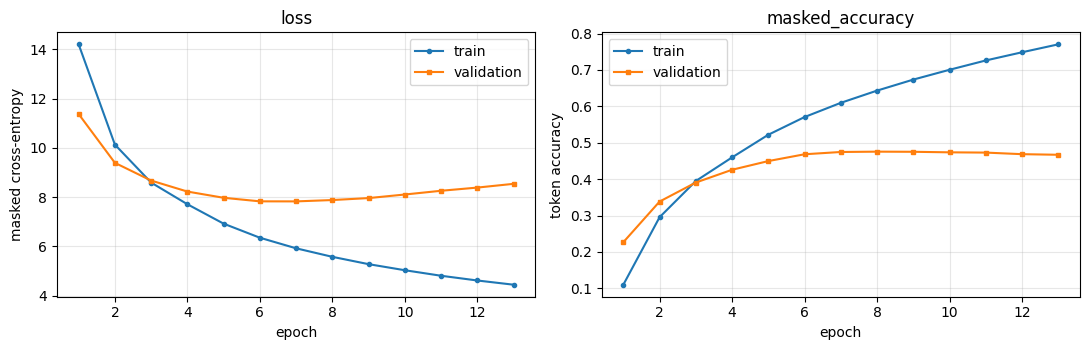

In [40]:
plt.figure(figsize=(11, 3.6))
for i, (key, label) in enumerate((("loss", "masked cross-entropy"),
                                  ("masked_accuracy", "token accuracy"))):
    plt.subplot(1, 2, i + 1)
    for prefix, style in (("", "o-"), ("val_", "s-")):
        values = history.history.get(prefix + key, [])
        plt.plot(range(1, len(values) + 1), values, style,
                 label=("train" if not prefix else "validation"), markersize=3)
    plt.title(key); plt.xlabel("epoch"); plt.ylabel(label); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig(OUT / "learning_curves.png", dpi=110); plt.show()

## 11. Does cross-attention agree with a human?

This is what the hand-aligned corpus makes possible. Feed the model a test sentence with its
*reference* translation (teacher forcing), read the cross-attention, and for every Vietnamese
token ask: is the English word the model attended to most the one a person linked it to?

Random attention over a 20-word English sentence would be right about 5–10% of the time, allowing
for the fact that a Vietnamese token often has several valid English sources. Anything well above
that is the model having learned alignment without ever being shown one.

Reported per decoder layer, because they do not behave the same — alignment tends to be sharpest
in the middle of the stack rather than at the end.

In [41]:
def gold_alignment(alignment, n_en, n_vi):
    """vietnamese index -> set of english indices, inverted from the corpus's en->vi links."""
    mapping = collections.defaultdict(set)
    for link in alignment.strip(";").split(";"):
        if "-" not in link:
            continue
        left, right = link.split("-", 1)
        try:
            source = int(left) - 1
            targets = [int(i) - 1 for i in right.split(",") if i]
        except ValueError:
            continue
        if 0 <= source < n_en:
            for t in targets:
                if 0 <= t < n_vi:
                    mapping[t].add(source)
    return mapping


if RUN_ALIGNMENT_CHECK:
    rows = [(i, r) for i, r in enumerate(data["test"]) if r[2]][:256]
    source_batch = np.array([test_sources[i] for i, _ in rows], np.int32)
    target_batch = np.array([vi_vocab.encode(r[1], MAX_LEN, True) for _, r in rows], np.int32)

    model((tf.constant(source_batch), tf.constant(target_batch[:, :-1])))
    layer_scores = model.attention_scores()      # each (B, heads, T, S)

    print(f"  {'layer':>6} {'agreement with the human alignment':>36} {'random':>9}")
    agreement_by_layer = {}
    for depth, scores_tensor in enumerate(layer_scores, start=1):
        averaged = np.array(scores_tensor).mean(axis=1)      # average the heads -> (B, T, S)
        hits = total = random_total = 0
        for b, (_, (en, vi, alignment)) in enumerate(rows):
            en_tokens, vi_tokens = tokens(en), tokens(vi)
            gold = gold_alignment(alignment, len(en_tokens), len(vi_tokens))
            for vi_index, en_indices in gold.items():
                if vi_index + 1 >= averaged.shape[1] or not en_indices:
                    continue
                # +1: decoder position 0 is <bos>, so vietnamese token j sits at position j+1
                predicted = int(averaged[b, vi_index + 1, :len(en_tokens)].argmax())
                hits += predicted in en_indices
                total += 1
                random_total += len(en_indices) / len(en_tokens)
        agreement = hits / max(total, 1)
        agreement_by_layer[depth] = agreement
        print(f"  {depth:>6} {agreement:>35.1%} {random_total / max(total, 1):>8.1%}")
    print(f"\n  {total:,} aligned Vietnamese tokens over {len(rows)} sentences")

   layer   agreement with the human alignment    random
       1                               25.3%     5.1%
       2                               40.9%     5.1%
       3                               28.3%     5.1%
       4                               27.6%     5.1%

  5,694 aligned Vietnamese tokens over 256 sentences


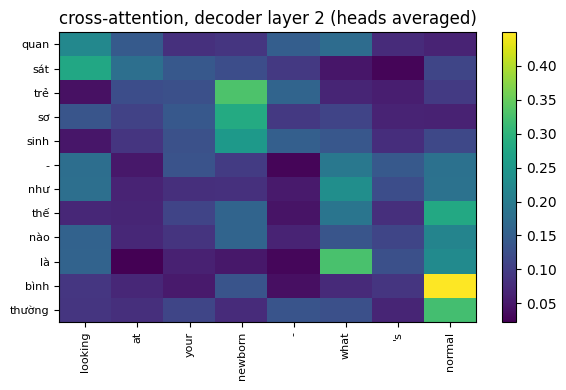

In [42]:
if RUN_ALIGNMENT_CHECK:
    best_layer = max(agreement_by_layer, key=agreement_by_layer.get)
    b = 0
    en, vi, _ = rows[b][1]
    en_tokens, vi_tokens = tokens(en), tokens(vi)
    weights = np.array(layer_scores[best_layer - 1]).mean(axis=1)[b]
    weights = weights[1:len(vi_tokens) + 1, :len(en_tokens)]

    plt.figure(figsize=(max(6, len(en_tokens) * 0.45), max(4, len(vi_tokens) * 0.3)))
    plt.imshow(weights, aspect="auto", cmap="viridis")
    plt.xticks(range(len(en_tokens)), en_tokens, rotation=90, fontsize=8)
    plt.yticks(range(len(vi_tokens)), vi_tokens, fontsize=8)
    plt.title(f"cross-attention, decoder layer {best_layer} (heads averaged)")
    plt.colorbar(); plt.tight_layout()
    plt.savefig(OUT / "cross_attention.png", dpi=110); plt.show()

In [43]:
metrics = {
    "scores": scores,
    "history": {k: [float(v) for v in vs] for k, vs in history.history.items()},
    "train_secs": round(TRAIN_SECONDS, 1),
    "epochs_run": EPOCHS_RUN,
    "best_epoch_by_accuracy": best_by_accuracy,
    "best_epoch_by_loss": best_by_loss,
    "params": int(model.count_params()),
    "gpu_speedup": GPU_SPEEDUP,
    "alignment_agreement": agreement_by_layer if RUN_ALIGNMENT_CHECK else None,
    "config": {"max_len": MAX_LEN, "en_vocab": len(en_vocab), "vi_vocab": len(vi_vocab),
               "num_layers": NUM_LAYERS, "d_model": D_MODEL, "num_heads": NUM_HEADS, "dff": DFF,
               "dropout": DROPOUT, "per_replica_batch": PER_REPLICA_BATCH,
               "global_batch": GLOBAL_BATCH, "replicas": N_REPLICAS, "epochs": EPOCHS,
               "warmup_steps": WARMUP_STEPS, "label_smoothing": LABEL_SMOOTHING,
               "seed": SEED, "gpu": [g.name for g in gpus], "platform": where},
    "pairs": {name: len(rows) for name, rows in data.items()},
}
with open(OUT / "translation_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=1)
model.save_weights(OUT / "transformer_en_vi.weights.h5")
print("saved to", OUT, ":", sorted(p.name for p in OUT.iterdir() if p.is_file()))

saved to /kaggle/working : ['cross_attention.png', 'learning_curves.png', 'transformer_en_vi.weights.h5', 'translation_metrics.json']


## 12. Reading these numbers honestly

- **40,000 sentence pairs is a small corpus for translation.** Published systems train on millions.
  A BLEU in the low teens from a 6M-parameter model on 40k pairs is what this scale produces; it
  is not evidence about the architecture.
- **The test set is 50 held-out documents**, so it is a fair split, but 50 documents of news is a
  narrow domain. The number would not transfer to conversational or technical text.
- **The alignment agreement is the result that does not depend on scale.** Cross-attention either
  points where a human pointed or it does not, and that is measurable on a small corpus.
- **One seed, one configuration, no tuning.**